# Assignment 9
## Submitted by Chaitanya Jindal

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

df = pd.read_csv("StudentsPerformance.csv")

df.columns = df.columns.str.strip()

print(f"Shape of dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape of dataset: (1000, 8)
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Part A: One-Sample Hypothesis Testing

#### Q1. Mean Math Score Test
##### Problem
Historically, the average math score in the district was 66.
Test whether the mean math score in this dataset is significantly greater than 66 at α = 0.05.

##### Hypotheses
 - H₀: μ ≤ 66
 - H₁: μ > 66

In [5]:
math_scores = df["math score"]

sample_mean = math_scores.mean()
sample_std = math_scores.std(ddof=1)
n = len(math_scores)

t_stat, p_two_tailed = stats.ttest_1samp(math_scores, popmean=66)

if t_stat > 0:
    p_value = p_two_tailed / 2
else:
    p_value = 1 - (p_two_tailed / 2)

print(f"Sample size: {n}")
print(f"Sample mean math score: {sample_mean:.2f}")
print(f"Sample standard deviation: {sample_std:.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value (one-tailed): {p_value:.4f}")

if p_value < 0.05:
    print(f"Conclusion: Reject H₀. The mean math score is significantly greater than 66.")
else:
    print(f"Conclusion: Fail to reject H₀. The mean math score is not significantly greater than 66.")

Sample size: 1000
Sample mean math score: 66.09
Sample standard deviation: 15.16
t-statistic: 0.1856
p-value (one-tailed): 0.4264
Conclusion: Fail to reject H₀. The mean math score is not significantly greater than 66.


#### Q2. Test Preparation Effect (Proportion Example)
##### Problem
Check whether the proportion of students who completed a test preparation course and scored above 70 in math is significantly greater than 50%.
##### Hypotheses
 - H₀: p ≤ 0.50
 - H₁: p > 0.50

In [6]:
success = ((df["test preparation course"] == "completed") & (df["math score"] > 70)).sum()
n = len(df)
p_hat = success / n
p0 = 0.50

z_stat = (p_hat - p0) / np.sqrt((p0 * (1 - p0)) / n)
p_value = 1 - norm.cdf(z_stat)

print(f"Number of successes: {success}")
print(f"Sample size: {n}")
print(f"Sample proportion of success: {p_hat:.4f}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"p-value (one-tailed): {p_value:.4f}")

if p_value < 0.05:
    print(f"Conclusion: Reject H₀. The proportion is significantly greater than 50%.")
else:
    print(f"Conclusion: Fail to reject H₀. The proportion is not significantly greater than 50%.")

Number of successes: 168
Sample size: 1000
Sample proportion of success: 0.1680
Z-statistic: -20.9975
p-value (one-tailed): 1.0000
Conclusion: Fail to reject H₀. The proportion is not significantly greater than 50%.


### Part B: Two-Sample Hypothesis Testing

#### Q3. Comparing Mean Math Scores by Gender
##### Problem
Test whether there is a significant difference in average math scores between male and female students.
##### Hypotheses
 - H₀: μmale = μfemale
 - H₁: μmale ≠ μfemale

Male mean math score: 68.73
Female mean math score: 63.63


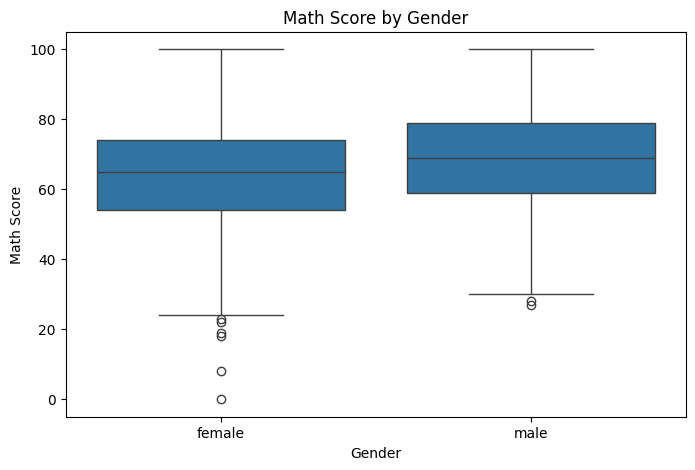

t-statistic: 5.3980
p-value: 0.0000
Conclusion: Reject H₀. There is a significant difference in math scores by gender.


In [7]:
male_math = df[df["gender"] == "male"]["math score"]
female_math = df[df["gender"] == "female"]["math score"]

print(f"Male mean math score: {male_math.mean():.2f}")
print(f"Female mean math score: {female_math.mean():.2f}")

plt.figure(figsize=(8, 5))
sns.boxplot(x="gender", y="math score", data=df)
plt.title("Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()

t_stat, p_value = stats.ttest_ind(male_math, female_math, equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"Conclusion: Reject H₀. There is a significant difference in math scores by gender.")
else:
    print(f"Conclusion: Fail to reject H₀. There is no significant difference in math scores by gender.")

#### Q4. Effect of Test Preparation Course on Writing Scores
##### Problem
Test whether there is a difference in mean writing scores between students who completed the test preparation course and those who did not.
##### Hypotheses
 - H₀: μcompleted = μnone
 - H₁: μcompleted ≠ μnone

Male mean math score: 68.73
Female mean math score: 63.63


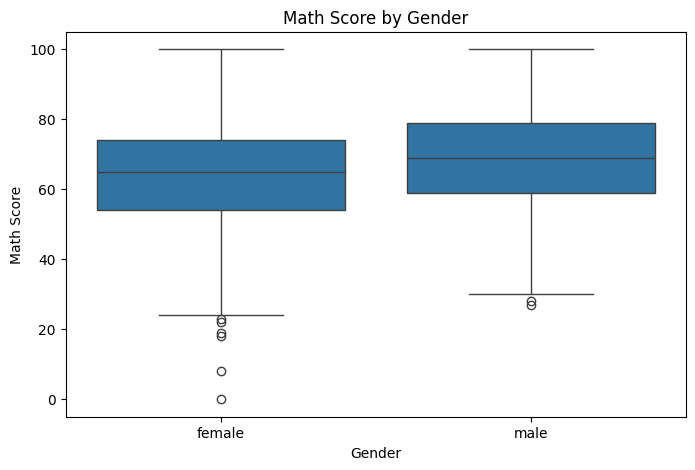

t-statistic: 5.3980
p-value: 0.0000
Conclusion: Reject H₀. There is a significant difference in math scores by gender.


In [8]:
male_math = df[df["gender"] == "male"]["math score"]
female_math = df[df["gender"] == "female"]["math score"]

print(f"Male mean math score: {male_math.mean():.2f}")
print(f"Female mean math score: {female_math.mean():.2f}")

plt.figure(figsize=(8, 5))
sns.boxplot(x="gender", y="math score", data=df)
plt.title("Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()

t_stat, p_value = stats.ttest_ind(male_math, female_math, equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"Conclusion: Reject H₀. There is a significant difference in math scores by gender.")
else:
    print(f"Conclusion: Fail to reject H₀. There is no significant difference in math scores by gender.")